# Logistic Regression from Scratch using NumPy

This notebook implements a complete **Logistic Regression** classifier from scratch using only **NumPy** for numerical computations and **Matplotlib** for visualization.

---

### Mathematical Formulation

#### 1. Hypothesis Function
Logistic Regression models the probability that a given input $X$ belongs to the positive class ($y = 1$). The hypothesis function is:
$$\hat{y} = \sigma(z) = \sigma(X w + b)$$
where:
* $X \in \mathbb{R}^{m \times n}$ is the input feature matrix ($m$ samples, $n$ features).
* $w \in \mathbb{R}^{n}$ is the weight vector.
* $b \in \mathbb{R}$ is the bias scalar.
* $\sigma(z)$ is the **Sigmoid (logistic) activation function**:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

#### 2. Cost Function (Binary Cross-Entropy)
To train the model, we minimize the Binary Cross-Entropy loss. We also support **L1 (Lasso)** and **L2 (Ridge)** regularization to prevent overfitting.

The cost function $J(w, b)$ is defined as:
$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right] + R(w)$$

Where $R(w)$ is the regularization penalty:
* **No regularization**: $R(w) = 0$
* **L1 Regularization**: $R(w) = \frac{\lambda}{m} \|w\|_1 = \frac{\lambda}{m} \sum_{j=1}^{n} |w_j|$
* **L2 Regularization**: $R(w) = \frac{\lambda}{2m} \|w\|_2^2 = \frac{\lambda}{2m} \sum_{j=1}^{n} w_j^2$

*(Note: We define $\lambda = \frac{1}{C}$ where $C$ is the inverse regularization strength, similar to scikit-learn).*

#### 3. Gradients
The partial derivatives of the cost function with respect to the weights $w$ and bias $b$ are:

$$\frac{\partial J}{\partial w} = \frac{1}{m} X^T (\hat{y} - y) + \frac{\partial R(w)}{\partial w}$$
$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

Where the gradient of the regularization term $\frac{\partial R(w)}{\partial w}$ is:
* **No regularization**: $0$
* **L1 Regularization**: $\frac{\lambda}{m} \text{sign}(w)$
* **L2 Regularization**: $\frac{\lambda}{m} w$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

## 1. Feature Preprocessing: StandardScaler
Standardizing features (mean = 0, standard deviation = 1) is essential for logistic regression, especially when using regularization or gradient descent optimization. We will implement `StandardScaler` from scratch.

In [2]:
class StandardScaler:
    """Standardize features by removing the mean and scaling to unit variance."""
    def __init__(self):
        self.mean_ = None
        self.scale_ = None

    def fit(self, X):
        """Compute the mean and standard deviation to be used for later scaling."""
        X = np.array(X, dtype=np.float64)
        self.mean_ = np.mean(X, axis=0)
        self.scale_ = np.std(X, axis=0)
        # Prevent division by zero for features with zero variance
        self.scale_[self.scale_ == 0.0] = 1.0
        return self

    def transform(self, X):
        """Perform standardization by centering and scaling."""
        if self.mean_ is None or self.scale_ is None:
            raise ValueError("StandardScaler instance is not fitted yet. Call 'fit' first.")
        X = np.array(X, dtype=np.float64)
        return (X - self.mean_) / self.scale_

    def fit_transform(self, X):
        """Fit to data, then transform it."""
        return self.fit(X).transform(X)

## 2. Logistic Regression Classifier
Now, we implement the `LogisticRegression` class. It supports:
* Fit intercept (bias term).
* Regularization options: `'l1'`, `'l2'`, or `None`.
* Three optimization solvers:
  * **`'gd'`**: Batch Gradient Descent (uses the entire dataset for each update).
  * **`'sgd'`**: Stochastic Gradient Descent (uses a single random sample per update).
  * **`'mini-batch'`**: Mini-batch Gradient Descent (uses a subset of samples per update).

In [3]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000, penalty=None, C=1.0, 
                 fit_intercept=True, solver='gd', batch_size=32, random_state=None):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.penalty = penalty
        self.C = C
        self.fit_intercept = fit_intercept
        self.solver = solver
        self.batch_size = batch_size
        self.random_state = random_state
        
        self.coef_ = None
        self.intercept_ = None
        self.loss_history_ = []

    def _sigmoid(self, z):
        # Clip z to avoid overflow error in exp
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _compute_loss(self, y, y_hat):
        m = len(y)
        # Avoid log(0) by clipping y_hat
        y_hat = np.clip(y_hat, 1e-15, 1 - 1e-15)
        bce = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
        
        # Add regularization penalty
        if self.penalty is None or self.C is None:
            return bce
        
        # lambda = 1 / C
        lambda_ = 1.0 / self.C
        if self.penalty == 'l2':
            reg = (lambda_ / (2 * m)) * np.sum(self.coef_ ** 2)
        elif self.penalty == 'l1':
            reg = (lambda_ / m) * np.sum(np.abs(self.coef_))
        else:
            reg = 0
            
        return bce + reg

    def _compute_gradients(self, X, y, y_hat):
        m = X.shape[0]
        error = y_hat - y
        
        # Gradients with respect to weights
        dw = (1 / m) * np.dot(X.T, error)
        
        # Gradients with respect to intercept
        db = (1 / m) * np.sum(error) if self.fit_intercept else 0.0
        
        # Add regularization gradient to weights
        if self.penalty is not None and self.C is not None:
            lambda_ = 1.0 / self.C
            if self.penalty == 'l2':
                dw += (lambda_ / m) * self.coef_
            elif self.penalty == 'l1':
                dw += (lambda_ / m) * np.sign(self.coef_)
                
        return dw, db

    def fit(self, X, y):
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.float64).reshape(-1)
        m, n = X.shape
        
        # Seed generator for reproducibility
        rng = np.random.default_rng(self.random_state)
        
        # Initialize weights and intercept
        self.coef_ = rng.normal(0, 0.01, size=n)
        self.intercept_ = 0.0
        self.loss_history_ = []
        
        if self.solver == 'gd':
            for i in range(self.n_iterations):
                z = np.dot(X, self.coef_) + self.intercept_
                y_hat = self._sigmoid(z)
                
                # Record loss
                loss = self._compute_loss(y, y_hat)
                self.loss_history_.append(loss)
                
                # Gradient update
                dw, db = self._compute_gradients(X, y, y_hat)
                self.coef_ -= self.learning_rate * dw
                if self.fit_intercept:
                    self.intercept_ -= self.learning_rate * db
                    
        elif self.solver == 'sgd':
            for i in range(self.n_iterations):
                indices = np.arange(m)
                rng.shuffle(indices)
                
                epoch_loss = 0
                for idx in indices:
                    xi = X[idx : idx + 1]
                    yi = y[idx : idx + 1]
                    
                    z = np.dot(xi, self.coef_) + self.intercept_
                    y_hat = self._sigmoid(z)
                    
                    loss = self._compute_loss(yi, y_hat)
                    epoch_loss += loss
                    
                    # Update weights on single sample
                    dw, db = self._compute_gradients(xi, yi, y_hat)
                    self.coef_ -= self.learning_rate * dw
                    if self.fit_intercept:
                        self.intercept_ -= self.learning_rate * db
                
                self.loss_history_.append(epoch_loss / m)
                
        elif self.solver == 'mini-batch':
            for i in range(self.n_iterations):
                indices = np.arange(m)
                rng.shuffle(indices)
                
                X_shuffled = X[indices]
                y_shuffled = y[indices]
                
                epoch_loss = 0
                batches = int(np.ceil(m / self.batch_size))
                for b in range(batches):
                    start = b * self.batch_size
                    end = min(start + self.batch_size, m)
                    
                    xb = X_shuffled[start:end]
                    yb = y_shuffled[start:end]
                    
                    z = np.dot(xb, self.coef_) + self.intercept_
                    y_hat = self._sigmoid(z)
                    
                    loss = self._compute_loss(yb, y_hat)
                    epoch_loss += loss * len(yb)
                    
                    dw, db = self._compute_gradients(xb, yb, y_hat)
                    self.coef_ -= self.learning_rate * dw
                    if self.fit_intercept:
                        self.intercept_ -= self.learning_rate * db
                        
                self.loss_history_.append(epoch_loss / m)
                
        return self

    def predict_proba(self, X):
        """Predict probability estimates for class 1."""
        X = np.array(X, dtype=np.float64)
        z = np.dot(X, self.coef_) + self.intercept_
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        """Predict class labels for samples in X."""
        probs = self.predict_proba(X)
        return (probs >= threshold).astype(int)

## 3. Metrics from Scratch
To evaluate the models without using `scikit-learn`, we implement our own classification metrics:
* Accuracy
* Precision
* Recall
* F1-Score
* Confusion Matrix

In [4]:
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision_score(y_true, y_pred):
    true_positives = np.sum((y_true == 1) & (y_pred == 1))
    predicted_positives = np.sum(y_pred == 1)
    if predicted_positives == 0:
        return 0.0
    return true_positives / predicted_positives

def recall_score(y_true, y_pred):
    true_positives = np.sum((y_true == 1) & (y_pred == 1))
    actual_positives = np.sum(y_true == 1)
    if actual_positives == 0:
        return 0.0
    return true_positives / actual_positives

def f1_score(y_true, y_pred):
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    if (p + r) == 0.0:
        return 0.0
    return 2 * (p * r) / (p + r)

def confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp], [fn, tp]])

## 4. Dataset Generation and Split
We generate a synthetic binary classification dataset using normal distributions. The dataset will have 2 features to allow 2D decision boundary visualization. We will manually split the dataset into 80% training and 20% testing sets.

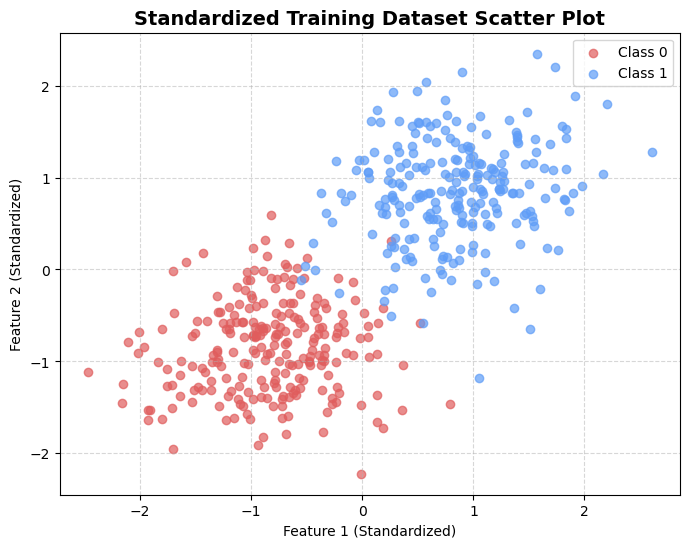

In [5]:
# Generate synthetic 2D data
def generate_synthetic_data(n_samples=500, random_state=42):
    rng = np.random.default_rng(random_state)
    # Class 0: centered at [-1.5, -1.5]
    X0 = rng.normal(loc=-1.5, scale=1.0, size=(n_samples // 2, 2))
    y0 = np.zeros(n_samples // 2)
    
    # Class 1: centered at [1.5, 1.5]
    X1 = rng.normal(loc=1.5, scale=1.0, size=(n_samples // 2, 2))
    y1 = np.ones(n_samples // 2)
    
    X = np.vstack((X0, X1))
    y = np.hstack((y0, y1))
    
    # Shuffle the dataset
    shuffled_indices = rng.permutation(n_samples)
    return X[shuffled_indices], y[shuffled_indices]

X, y = generate_synthetic_data(n_samples=600, random_state=42)

# Manual Train-Test Split (80% Train, 20% Test)
def train_test_split(X, y, test_size=0.2, random_state=42):
    rng = np.random.default_rng(random_state)
    m = X.shape[0]
    test_count = int(m * test_size)
    
    shuffled_indices = rng.permutation(m)
    test_indices = shuffled_indices[:test_count]
    train_indices = shuffled_indices[test_count:]
    
    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data using our StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Plot the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X_train_scaled[y_train == 0][:, 0], X_train_scaled[y_train == 0][:, 1], color='#E05D5D', alpha=0.7, label='Class 0')
plt.scatter(X_train_scaled[y_train == 1][:, 0], X_train_scaled[y_train == 1][:, 1], color='#5F9DF7', alpha=0.7, label='Class 1')
plt.title("Standardized Training Dataset Scatter Plot", fontsize=14, fontweight='bold')
plt.xlabel("Feature 1 (Standardized)")
plt.ylabel("Feature 2 (Standardized)")
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 5. Model Training & Comparison of Solvers
We will train three distinct logistic regression configurations:
1. **Batch Gradient Descent (GD) without Regularization**
2. **Mini-batch Gradient Descent without Regularization** (batch size = 32)
3. **Batch Gradient Descent (GD) with L2 Regularization** ($C = 0.5$)

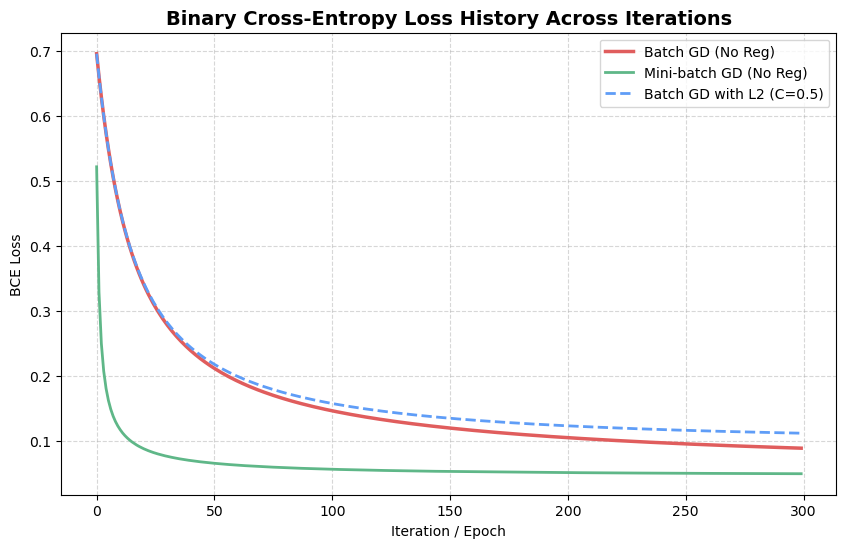

In [6]:
# 1. Batch Gradient Descent
model_gd = LogisticRegression(learning_rate=0.1, n_iterations=300, penalty=None, solver='gd', random_state=42)
model_gd.fit(X_train_scaled, y_train)

# 2. Mini-batch Gradient Descent
model_mb = LogisticRegression(learning_rate=0.1, n_iterations=300, penalty=None, solver='mini-batch', batch_size=32, random_state=42)
model_mb.fit(X_train_scaled, y_train)

# 3. Batch GD with L2 Regularization
model_l2 = LogisticRegression(learning_rate=0.1, n_iterations=300, penalty='l2', C=0.5, solver='gd', random_state=42)
model_l2.fit(X_train_scaled, y_train)

# Plot the training loss curves
plt.figure(figsize=(10, 6))
plt.plot(model_gd.loss_history_, label='Batch GD (No Reg)', color='#E05D5D', linewidth=2.5)
plt.plot(model_mb.loss_history_, label='Mini-batch GD (No Reg)', color='#5FB788', linewidth=2)
plt.plot(model_l2.loss_history_, label='Batch GD with L2 (C=0.5)', color='#5F9DF7', linewidth=2, linestyle='--')
plt.title("Binary Cross-Entropy Loss History Across Iterations", fontsize=14, fontweight='bold')
plt.xlabel("Iteration / Epoch")
plt.ylabel("BCE Loss")
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 6. Evaluation and Metrics Comparison
Let's print the classification performance metrics (Accuracy, Precision, Recall, F1-Score) for each trained model configuration on the testing set.

In [7]:
models = {
    "Batch GD (No Reg)": model_gd,
    "Mini-batch GD (No Reg)": model_mb,
    "Batch GD L2 (C=0.5)": model_l2
}

print(f"{'Model Configuration':<25} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 75)

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    print(f"{name:<25} | {acc:<10.4f} | {prec:<10.4f} | {rec:<10.4f} | {f1:<10.4f}")

Model Configuration       | Accuracy   | Precision  | Recall     | F1-Score  
---------------------------------------------------------------------------
Batch GD (No Reg)         | 0.9750     | 0.9667     | 0.9831     | 0.9748    
Mini-batch GD (No Reg)    | 0.9667     | 0.9508     | 0.9831     | 0.9667    
Batch GD L2 (C=0.5)       | 0.9750     | 0.9667     | 0.9831     | 0.9748    


## 7. Decision Boundary Visualization
A linear logistic regression model constructs a linear decision boundary where:
$$w_1 x_1 + w_2 x_2 + b = 0$$

Solving for $x_2$:
$$x_2 = -\frac{w_1 x_1 + b}{w_2}$$

Let's plot the decision boundaries for the trained models overlaid on the test dataset.

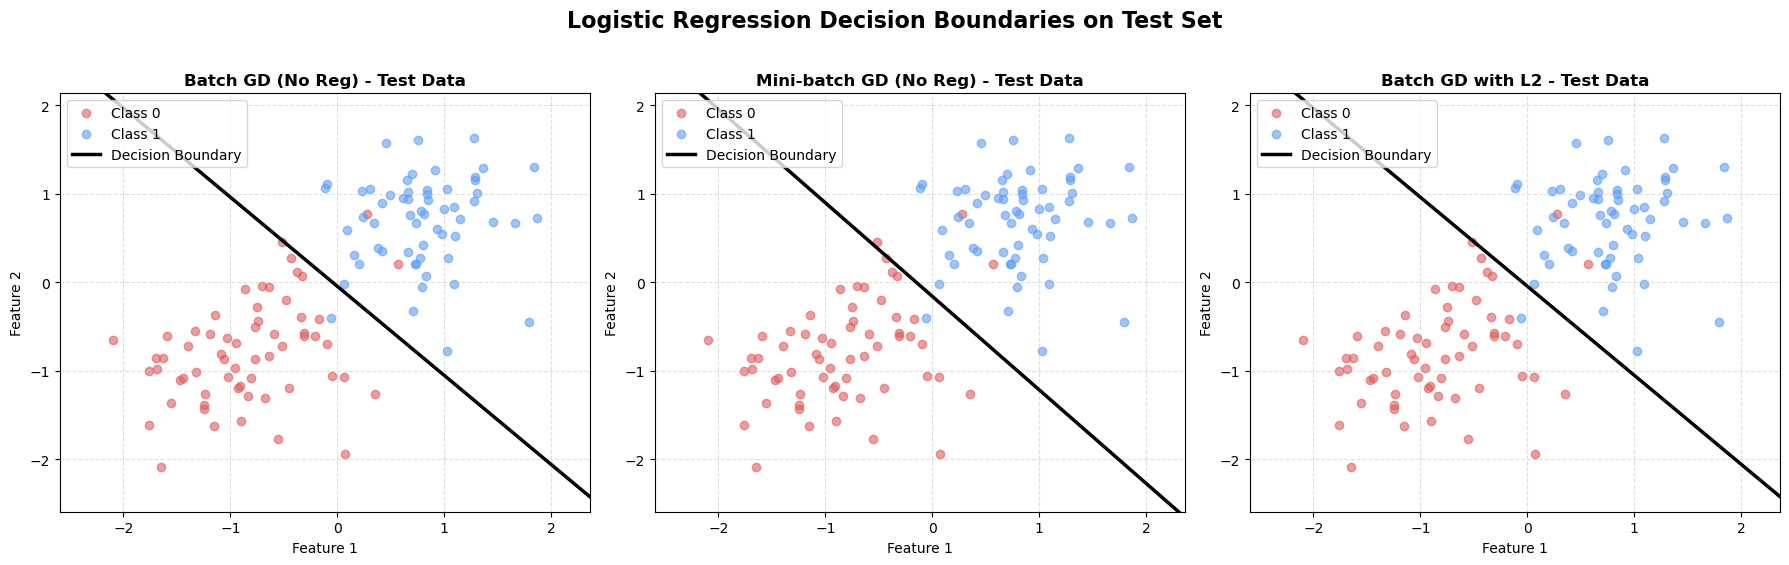

In [8]:
def plot_decision_boundary(model, X_data, y_data, title, ax):
    # Scatter plot of classes
    ax.scatter(X_data[y_data == 0][:, 0], X_data[y_data == 0][:, 1], color='#E05D5D', alpha=0.6, label='Class 0')
    ax.scatter(X_data[y_data == 1][:, 0], X_data[y_data == 1][:, 1], color='#5F9DF7', alpha=0.6, label='Class 1')
    
    # Calculate decision boundary line
    w1, w2 = model.coef_
    b = model.intercept_
    
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5
    
    x_boundary = np.array([x_min, x_max])
    y_boundary = -(w1 * x_boundary + b) / w2
    
    ax.plot(x_boundary, y_boundary, color='black', linewidth=2.5, linestyle='-', label='Decision Boundary')
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper left')

# Plot decision boundaries on Test Data
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
plot_decision_boundary(model_gd, X_test_scaled, y_test, "Batch GD (No Reg) - Test Data", axes[0])
plot_decision_boundary(model_mb, X_test_scaled, y_test, "Mini-batch GD (No Reg) - Test Data", axes[1])
plot_decision_boundary(model_l2, X_test_scaled, y_test, "Batch GD with L2 - Test Data", axes[2])

plt.suptitle("Logistic Regression Decision Boundaries on Test Set", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("logistic_regression_demo.png", dpi=150, bbox_inches='tight')
plt.show()